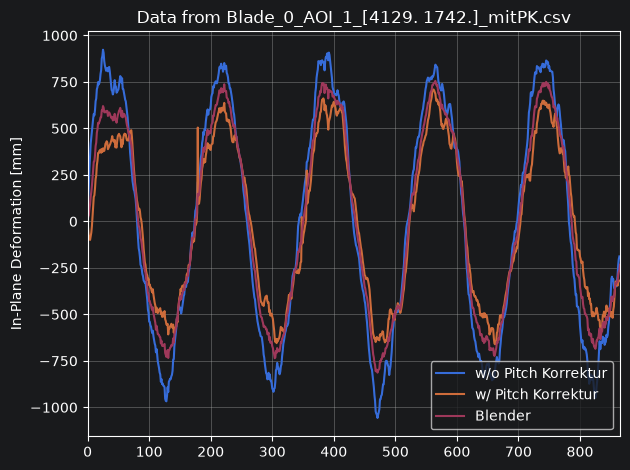

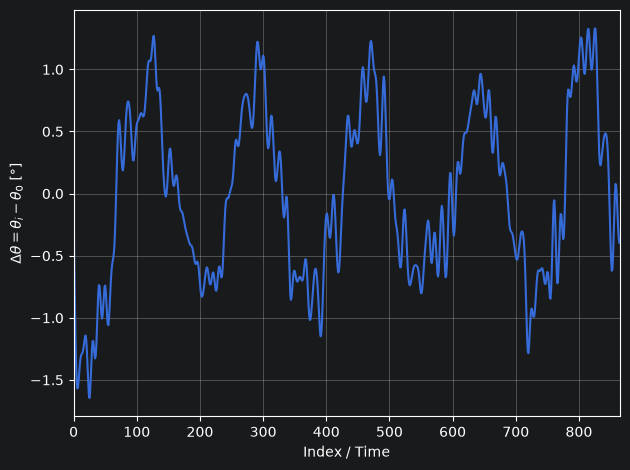

In [2]:
%reset -f
# %matplotlib qt

import os
import easygui
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

# Plot deformation

plt.close("all")

v_i = 0
v_f = 865

# Open file dialog to select a .mat file
pitch_angle_file = r"C:\Users\printezis_adm\Desktop\tfd-wea-dic\sandbox\BLENDER Blade BLADE_A_1.csv" # easygui.fileopenbox("Select the .mat file")






file_path_wo_pitch_korr = r"Blade_0_AOI_1_[4129. 1742.]_ohnePK.csv" # easygui.fileopenbox("Select the .csv file without correction")
file_path_w_pitch_korr = r"Blade_0_AOI_1_[4129. 1742.]_mitPK.csv" # easygui.fileopenbox("Select the .csv file with correction")
fig = plt.figure()
ax = fig.add_subplot(111)

# pitch_angle_data = scipy.io.loadmat(pitch_angle_file)
# pitch_angle_data = pitch_angle_data["pitch_wea_bladeA"].flatten()


pitch_angle_data = pd.read_csv(pitch_angle_file, sep=";", decimal=",") # TODO: only for test

schwenk_data = -pitch_angle_data[" Schwenk"].to_numpy()
pitch_angle_data = -pitch_angle_data[" Winkel"].to_numpy()


pitch_angle_data = pitch_angle_data[v_i:v_f] - pitch_angle_data[0]

path_list = [file_path_wo_pitch_korr, file_path_w_pitch_korr]
for path in path_list[:]:
    filename = os.path.basename(path)
    df_w_pitch = pd.read_csv(path, sep=";", decimal=',', skiprows=1, header=0)

    y_pos = df_w_pitch["Y [mm]"].to_numpy(copy=True)[v_i:v_f]
    sigma = df_w_pitch["sigma [pixel]"].to_numpy(copy=True)[v_i:v_f]
    deformation_V = df_w_pitch["V [mm]"].to_numpy(copy=True)[v_i:v_f]

    bad_sigmas = np.nonzero(sigma < 0)[0]
    deformation_V[bad_sigmas] = 0

    ax.plot(deformation_V, label=filename)


ax.plot(schwenk_data)
ax.set_title(f"Data from {filename}")

ax.set_ylabel("In-Plane Deformation [mm]")
ax.grid(True)
ax.set_xlim(v_i, v_f)
ax.legend(["w/o Pitch Korrektur", "w/ Pitch Korrektur", "Blender"])
plt.tight_layout()
plt.show()

# Create a plot for the variables found
fig1 = plt.figure()
ax1 = fig1.add_subplot()

ax1.plot(pitch_angle_data)

ax1.set_xlabel("Index / Time")
ax1.set_ylabel(r"$\Delta \theta = \theta_{i} - \theta_{0}$ [°]")
ax1.grid(True)
ax1.set_xlim(v_i, v_f)
plt.tight_layout()
plt.show()

In [4]:
%reset -f
%matplotlib qt

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares

from coordsysalign.multiprocessing_fns import read_file
from coordsysalign.transformation_fns import calculate_circle_rotation_matrix_2, residuals, rotation_matrix_z, \
    find_blade_axis


def generate_cylinder_mesh(p0, axis_dir, radius, height, num_segments=300):
    axis_dir = axis_dir / np.linalg.norm(axis_dir)

    # Compute perpendicular basis vectors u and v
    if np.allclose(axis_dir[:2], 0):
        u = np.array([1.0, 0.0, 0.0])
    else:
        u = np.array([-axis_dir[1], axis_dir[0], 0.0])
    u = u / np.linalg.norm(u)
    v = np.cross(axis_dir, u)

    theta = np.linspace(0, 2 * np.pi, num_segments)
    h = np.linspace(-height / 2, height / 2, 2)
    THETA, H = np.meshgrid(theta, h)

    X = (
            p0[0]
            + H * axis_dir[0]
            + radius * (np.cos(THETA) * u[0] + np.sin(THETA) * v[0])
    )
    Y = (
            p0[1]
            + H * axis_dir[1]
            + radius * (np.cos(THETA) * u[1] + np.sin(THETA) * v[1])
    )
    Z = (
            p0[2]
            + H * axis_dir[2]
            + radius * (np.cos(THETA) * u[2] + np.sin(THETA) * v[2])
    )

    return X, Y, Z


plt.close("all")

blade_name_list = ["A", "B", "C"]
hub_aoi_array = np.array([0, 1, 2])
aoi_blade_num_array = np.array([0.0, 1.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0])

out_file = "messung24_000982_0.out"

visibility_f0, coordinates_f0, xyz_sigmas_f0, aoi_number_f0, index_in_aoi_f0 = read_file(out_file, None)
visible_idxs_f0 = np.nonzero(visibility_f0 > 0)[::10]
coordinates_f0 = coordinates_f0[visible_idxs_f0]
aoi_number_f0 = aoi_number_f0[visible_idxs_f0]

LEGEND_FLAG = True

fig = plt.figure()
ax = fig.add_subplot(231, projection="3d")
ax2 = fig.add_subplot(232, projection="3d")
ax3 = fig.add_subplot(233, projection="3d")
ax4 = fig.add_subplot(234, projection="3d")
ax5 = fig.add_subplot(235, projection="3d")
ax6 = fig.add_subplot(236, projection="3d")

p0_list = []
axis_dir_list = []
blade_rad_list = []
for blade_idx, blade_name in enumerate(blade_name_list[:1]):

    # Find the indices/AoIs in the current blade
    aoi_in_blade_array = np.nonzero(aoi_blade_num_array == blade_idx)[0]

    for aoi_in_blade in aoi_in_blade_array[1::-1]:
        # tip_aoi = aoi_in_blade_array[np.argmax(aoi_to_blade_aoi[aoi_in_blade_array])]
        tip_indices = np.nonzero(aoi_number_f0 == aoi_in_blade)[0]

        if tip_indices.size != 0:
            tip_points = coordinates_f0[tip_indices]
            tip_avg_coord = np.mean(tip_points, axis=0)
            break
        else:
            continue

    # Isolate the points belonging to the AoIs closest to the rotor hub
    blade_hub_idx_array = np.nonzero(aoi_number_f0 == hub_aoi_array[blade_idx])[0]
    hub_points = coordinates_f0[blade_hub_idx_array]
    hub_avg_coord = np.mean(hub_points, axis=0)

    blade_anchor, blade_dir, blade_rad = find_blade_axis(hub_points, tip_points)

    # # Indices for the blade
    complete_blade_idx_array = np.nonzero(np.isin(aoi_number_f0, aoi_in_blade_array))[0]
    blade_points = coordinates_f0[complete_blade_idx_array]

    height = 1500  #h_max - h_min

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        blade_anchor, blade_dir, blade_rad, height=height
    )

    # Cylinder central axis line
    axis_pts = np.array(
        [
            blade_anchor - blade_dir * (height / 2 + 50),
            blade_anchor + blade_dir * (height / 2 + 50),
        ]
    )

    # Scatter plot of original points
    ax.scatter(
        hub_points[:, 0],
        hub_points[:, 1],
        hub_points[:, 2],
        color="magenta",
        s=10,
        label="Points used for Cylinder fit"
    )

    ax.scatter(
        blade_points[:, 0],
        blade_points[:, 1],
        blade_points[:, 2],
        color="yellow",
        s=10,
        alpha=0.4,
        label="Raw Blade Points"
    )

    # ax.plot(
    #     axis_pts[:, 0],
    #     axis_pts[:, 1],
    #     axis_pts[:, 2],
    #     "b--",
    #     linewidth=2,
    #     label="Cylinder Axis",
    # )
    ax.plot(
        blade_anchor[0],
        blade_anchor[1],
        blade_anchor[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(blade_anchor, 1)} mm",
    )

    ax.quiver(
        blade_anchor[0],
        blade_anchor[1],
        blade_anchor[2],
        blade_dir[0],
        blade_dir[1],
        blade_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(blade_dir, 3)}",
        length=10000,
    )

    # Cylinder wireframe mesh
    ax.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
        label="Fitted Cylinder"
    )

    centered_points = hub_points - blade_anchor
    centered_blade_points = blade_points - blade_anchor
    centered_center_p0 = blade_anchor - blade_anchor

    # Scatter plot of original points

    ax2.scatter(
        centered_blade_points[:, 0],
        centered_blade_points[:, 1],
        centered_blade_points[:, 2],

        color="yellow",
        s=10,
        alpha=0.4,
    )

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        centered_center_p0, blade_dir, blade_rad, height=height
    )

    ax2.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
    )

    ax2.plot(
        centered_center_p0[0],
        centered_center_p0[1],
        centered_center_p0[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(centered_center_p0, 1)} mm",
    )

    ax2.quiver(
        centered_center_p0[0],
        centered_center_p0[1],
        centered_center_p0[2],
        blade_dir[0],
        blade_dir[1],
        blade_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(blade_dir, 3)}",
        length=10000,
    )

    first_rot = calculate_circle_rotation_matrix_2(blade_dir, 1)

    rotated_points = np.dot(first_rot, centered_points.T).T
    rotated_blade_points = np.dot(first_rot, centered_blade_points.T).T
    rotated_center_p0 = np.dot(first_rot, centered_center_p0.T).T

    rotated_axis_dir = np.matmul(first_rot, blade_dir)

    # Scatter plot of original points

    ax3.scatter(
        rotated_blade_points[:, 0],
        rotated_blade_points[:, 1],
        rotated_blade_points[:, 2],

        color="yellow",
        s=10,
        alpha=0.4,
    )

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        rotated_center_p0, rotated_axis_dir, blade_rad, height=height
    )

    ax3.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
    )

    ax3.plot(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(rotated_center_p0, 1)} mm",
    )

    ax3.quiver(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        rotated_axis_dir[0],
        rotated_axis_dir[1],
        rotated_axis_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(rotated_axis_dir, 3)}",
        length=10000,
    )

    second_rot = rotation_matrix_z(np.pi / 2)

    old_rotated_blade_points = rotated_blade_points

    rotated_points = np.dot(second_rot, rotated_points.T).T
    rotated_blade_points = np.dot(second_rot, rotated_blade_points.T).T
    rotated_center_p0 = np.dot(second_rot, rotated_center_p0.T).T

    rotated_axis_dir = np.matmul(second_rot, rotated_axis_dir)

    ax4.scatter(
        old_rotated_blade_points[:, 0],
        old_rotated_blade_points[:, 1],
        old_rotated_blade_points[:, 2],

        color="yellow",
        s=10,
        alpha=0.4,
        label="w/ Pitch Angle"
    )

    ax4.scatter(
        rotated_blade_points[:, 0],
        rotated_blade_points[:, 1],
        rotated_blade_points[:, 2],

        color="lime",
        s=10,
        alpha=0.4,
        label="w/o Pitch Angle"
    )

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        rotated_center_p0, rotated_axis_dir, blade_rad, height=height
    )

    ax4.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
    )

    ax4.plot(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(rotated_center_p0, 1)} mm",
    )

    ax4.quiver(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        rotated_axis_dir[0],
        rotated_axis_dir[1],
        rotated_axis_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(rotated_axis_dir, 3)}",
        length=10000,
    )

    third_rot = np.linalg.inv(first_rot)

    rotated_points = np.dot(third_rot, rotated_points.T).T
    rotated_blade_points = np.dot(third_rot, rotated_blade_points.T).T
    rotated_center_p0 = np.dot(third_rot, rotated_center_p0.T).T

    rotated_axis_dir = np.matmul(third_rot, rotated_axis_dir)

    ax5.scatter(
        centered_blade_points[:, 0],
        centered_blade_points[:, 1],
        centered_blade_points[:, 2],

        color="yellow",
        s=10,
        alpha=0.4,
    )

    ax5.scatter(
        rotated_blade_points[:, 0],
        rotated_blade_points[:, 1],
        rotated_blade_points[:, 2],

        color="lime",
        s=10,
        alpha=0.4,
    )

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        rotated_center_p0, rotated_axis_dir, blade_rad, height=height
    )

    ax5.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
    )

    ax5.plot(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(rotated_center_p0, 1)} mm",
    )

    ax5.quiver(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        rotated_axis_dir[0],
        rotated_axis_dir[1],
        rotated_axis_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(rotated_axis_dir, 3)}",
        length=10000,
    )

    rotated_points = rotated_points + blade_anchor
    rotated_blade_points = rotated_blade_points + blade_anchor
    rotated_center_p0 = rotated_center_p0 + blade_anchor

    # Scatter plot of original points
    ax6.scatter(
        rotated_blade_points[:, 0],
        rotated_blade_points[:, 1],
        rotated_blade_points[:, 2],
        color="lime",
        s=10,
    )

    ax6.scatter(
        blade_points[:, 0],
        blade_points[:, 1],
        blade_points[:, 2],

        color="yellow",
        s=10,
        alpha=0.4,
    )

    X_mesh, Y_mesh, Z_mesh = generate_cylinder_mesh(
        rotated_center_p0, rotated_axis_dir, blade_rad, height=height
    )

    ax6.plot_wireframe(
        X_mesh,
        Y_mesh,
        Z_mesh,
        color="cyan",
        alpha=0.4,
    )

    ax6.plot(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        "x",
        linewidth=2,
        color="magenta",
        label=f"Cylinder Origin: {np.round(rotated_center_p0, 1)} mm",
    )

    ax6.quiver(
        rotated_center_p0[0],
        rotated_center_p0[1],
        rotated_center_p0[2],
        rotated_axis_dir[0],
        rotated_axis_dir[1],
        rotated_axis_dir[2],
        normalize=True,
        color="white",
        label=f"Blade axis: {np.round(rotated_axis_dir, 3)}",
        length=10000,
    )

p0_array = np.array(p0_list)
axis_dir_array = np.array(axis_dir_list)
blade_rad_array = np.array(blade_rad_list)

# Labels, title, and display settings
ax.set_title("Punkte aus .out Datei")
ax.set_xlabel("x", weight='bold')
ax.set_ylabel("y", weight='bold')
ax.set_zlabel("z", weight='bold')
ax.axis("equal")

ax2.set_title("Blattwürzel zum Ursprung Bringen")
ax2.set_xlabel("x", weight='bold')
ax2.set_ylabel("y", weight='bold')
ax2.set_zlabel("z", weight='bold')
ax2.axis("equal")

ax3.set_title("Blattachse in die z-Richtung bringen")
ax3.set_xlabel("x", weight='bold')
ax3.set_ylabel("y", weight='bold')
ax3.set_zlabel("z", weight='bold')
ax3.axis("equal")

ax4.set_title("Pitch-Winkel Eliminierung (Rotation um die z-Achse)")
ax4.set_xlabel("x", weight='bold')
ax4.set_ylabel("y", weight='bold')
ax4.set_zlabel("z", weight='bold')
ax4.axis("equal")

ax5.set_title("Blattachse wieder in ursprüngliche Richtung bringen")
ax5.set_xlabel("x", weight='bold')
ax5.set_ylabel("y", weight='bold')
ax5.set_zlabel("z", weight='bold')
ax5.axis("equal")

ax6.set_title("Blattwürzel zu den ursprünglichen Koordinaten zurückführen")
ax6.set_xlabel("x", weight='bold')
ax6.set_ylabel("y", weight='bold')
ax6.set_zlabel("z", weight='bold')
ax6.axis("equal")

if LEGEND_FLAG:
    ax.legend()
    ax2.legend()
    ax3.legend()
    ax4.legend()
    ax5.legend()
    ax6.legend()



In [1]:
# Test pitch correction

%reset -f
%matplotlib qt

import matplotlib.pyplot as plt
import numpy as np

from coordsysalign.multiprocessing_fns import read_file
from coordsysalign.transformation_fns import correct_pitch_in_out_file, find_blade_axis

plt.close("all")

blade_name_list = ["A", "B", "C"]
hub_aoi_array = np.array([0, 1, 2])
aoi_blade_num_array = np.array([0.0, 1.0, 2.0, 1.0, 1.0, 1.0, 2.0, 2.0, 2.0, 0.0, 0.0, 0.0])

out_file = "messung24_000982_0.out"

visibility_f0, coordinates_f0, xyz_sigmas_f0, aoi_number_f0, index_in_aoi_f0 = read_file(out_file, None)
visible_idxs_f0 = np.nonzero(visibility_f0 > 0)[0]
coordinates_f0 = coordinates_f0[visible_idxs_f0]
aoi_number_f0 = aoi_number_f0[visible_idxs_f0]

new_out_file = correct_pitch_in_out_file(out_file, 90, hub_aoi_array, blade_name_list, aoi_blade_num_array,
                                         "pitch_corr")

visibility_new, coordinates_new, xyz_sigmas_new, aoi_number_new, index_in_aoi_new = read_file(new_out_file, None)
visible_idxs_new = np.nonzero(visibility_new > 0)[0]
coordinates_new = coordinates_new[visible_idxs_new]
aoi_number_new = aoi_number_new[visible_idxs_new]

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.scatter(coordinates_f0[:, 0], coordinates_f0[:, 1], coordinates_f0[:, 2], color="magenta",
           s=10,
           label="OG")
ax.scatter(coordinates_new[:, 0], coordinates_new[:, 1], coordinates_new[:, 2], color="blue",
           s=10,
           label="New")
ax.set_title("Punkte aus .out Datei")
ax.set_xlabel("x", weight='bold')
ax.set_ylabel("y", weight='bold')
ax.set_zlabel("z", weight='bold')
ax.axis("equal")
ax.legend()


KKKKKK
KKKKKK
KKKKKK


In [5]:

from vicpyx import VicDataSet

dataset = VicDataSet()
input_file = "messung19_000621_0.out"

if dataset.load(input_file) == False:
    raise RuntimeError(f"Failed to load file: {input_file}")

# 2. Retrieve variables you want to modify or use for calculation
data_all = dataset.get_values(["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y", "SIGMA_Z"])

data["U"] = data["U"] + 22

n_aoi = dataset.num_data()

data_aoi0 = dataset.data(0).get_values(["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y", "SIGMA_Z"])

# 5. Overwrite or add variables back to the VicDataSet object
dataset.set_values(data)  # Overwrites existing 'U'

# 6. Save as a new .out file (or overwrite the existing one)
output_file = "modified_data.out"
dataset.save(output_file)

print(f"Successfully modified and saved to: {output_file}")

NameError: Unable to find file: messung19_000621_0.out or file is corrupted

In [ ]:
%reset -f
import numpy as np
from vicpyx import VicDataSet
from coordsysalign.multiprocessing_fns import read_file
from coordsysalign.transformation_fns import find_blade_axis

input_file = "messung24_000982_0.out"

visibility_ref, coordinates_ref, xyz_sigmas_ref, aoi_number_ref, index_in_aoi_ref = read_file(input_file, None)


def correct_pitch_in_out_file(out_file, pitch_angle_list=[], aoi_ids_near_center, blade_name_list, blade_number_of_aoi):
    # Load .out file as VicDataSet instance, basically a reformed version of read_file function. TODO: I should probably rewrite that one.
    dataset = VicDataSet()

    if dataset.load(input_file) == False:
        print("Could not load data set\n")
        exit(-1)

    size_tot = dataset.matrix_size()
    data = dataset.get_values(["sigma", "X", "Y", "Z", "U", "V", "W", "SIGMA_X", "SIGMA_Y", "SIGMA_Z"])

    visibility = np.where(data["sigma"] < 0, 0, 1)

    coordinates = np.empty((size_tot, 3))
    coordinates[:, 0] = data["X"] + data["U"]
    coordinates[:, 1] = data["Y"] + data["V"]
    coordinates[:, 2] = data["Z"] + data["W"]
    new_coordinates = np.empty(coordinates)

    xyz_sigmas = np.empty((size_tot, 3))
    xyz_sigmas[:, 0] = data["SIGMA_X"]
    xyz_sigmas[:, 1] = data["SIGMA_Y"]
    xyz_sigmas[:, 2] = data["SIGMA_Z"]

    aoi_n = dataset.num_data()
    aoi_number_list = []
    index_in_aoi_list = []
    for aoi in range(aoi_n):
        aoi_data = dataset.data(aoi)
        aoi_number_list.extend(aoi_data.matrix_size() * [aoi])
        index_in_aoi_list.extend(np.arange(aoi_data.matrix_size()))
    aoi_number = np.array(aoi_number_list)
    index_in_aoi = np.array(index_in_aoi_list)

    found_idx = np.nonzero(visibility == 1)[0]
    found_coordinates = coordinates[found_idx]
    found_aoi_number = aoi_number[found_idx]

    for blade_idx, blade_name in enumerate(blade_name_list):
        blade_root_idxs = np.nonzero(found_aoi_number == aoi_ids_near_center[blade_idx])[0]
        blade_root_coords = found_coordinates[blade_root_idxs]

        aoi_in_blade_array = np.nonzero(blade_number_of_aoi == blade_idx)[0]

        for aoi_in_blade in aoi_in_blade_array[1::-1]:
            blade_tip_idxs = np.nonzero(found_aoi_number == aoi_in_blade)[0]

            if tip_indices.size != 0:
                blade_tip_coords = coordinates[blade_tip_idxs]
                break
            else:
                continue

        blade_anchor_pt, blade_dir, blade_rad = find_blade_axis(blade_root_coords, blade_tip_coords)

        # Using the stuff
        blade_point_idxs = np.nonzero(np.isin(aoi_number, aoi_in_blade_array))[0]
        blade_point_coords = coordinates[blade_point_idxs]

        first_rot = calculate_circle_rotation_matrix_2(blade_dir, 1)
        second_rot = rotation_matrix_z(np.deg2rad(90))  #rotation_matrix_z(np.deg2rad(pitch_angle_data[out_file_idx]))
        third_rot = np.linalg.inv(first_rot)
        total_pitch_rot = np.matmul(third_rot, np.matmul(second_rot, first_rot))

        blade_point_coords_wo_pitch = np.dot(total_pitch_rot,
                                             (blade_point_coords - blade_anchor_pt).T).T + blade_anchor_pt

        new_coordinates[blade_point_idxs] = blade_point_coords_wo_pitch

    new_u = new_coordinates - data["X"]
    new_v = new_coordinates - data["Y"]
    new_w = new_coordinates - data["Z"]
    dataset.set_values({"U": new_u, "V": new_v, "W": new_w})

    if dataset.save(out_file) == False:
        print("Could not save the dataset\n")
        exit(-1)




